In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv('global_cancer_patients_2015_2024 (1).csv')

In [3]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [5]:
data.duplicated().sum()

0

# Descriptive Analysis

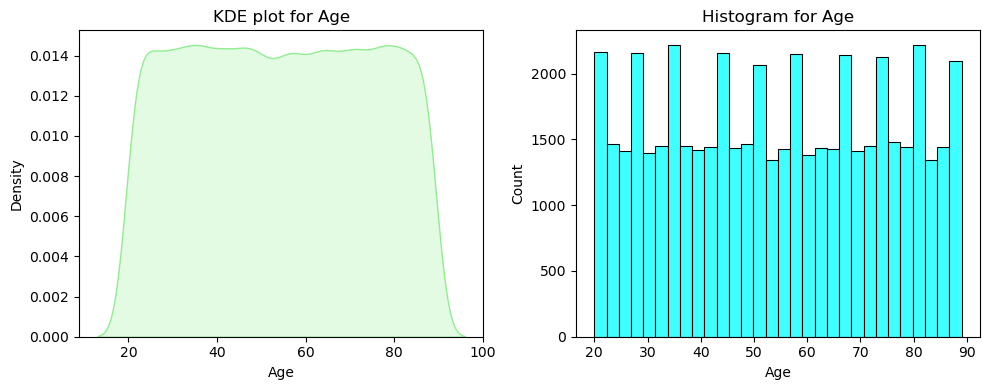

In [6]:
# plotting for age columns

plt.figure(figsize= (10,4))

plt.subplot(1,2,1)
sns.kdeplot(data['Age'],fill= True, color= "lightgreen")
plt.title("KDE plot for Age")

plt.subplot(1,2,2)
sns.histplot(data['Age'], bins=30,color= "cyan")
plt.title('Histogram for Age')

plt.tight_layout()
plt.show()

In [7]:
data['Age'].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

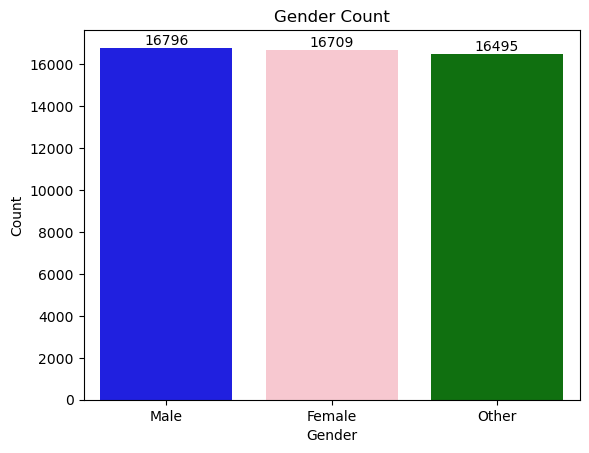

In [8]:
# Gender column

sns.barplot(x=data['Gender'].value_counts().index,
            y= data['Gender'].value_counts().values,
             palette= ['blue', 'pink', 'green'])
for i,v in enumerate(data['Gender'].value_counts()):
    plt.text(i,v, str(v), ha= 'center', va='bottom')

plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

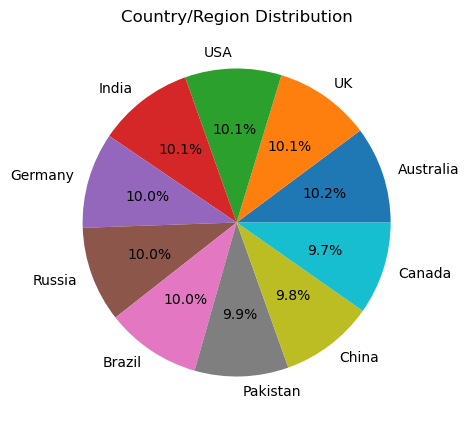

In [9]:
# Countries column

country_counts=data['Country_Region'].value_counts()

plt.figure(figsize= (5,5))
plt.pie(x= country_counts.values,
        labels= country_counts.index,
        autopct= '%1.1f%%'
       )

plt.title('Country/Region Distribution')
plt.show()
        

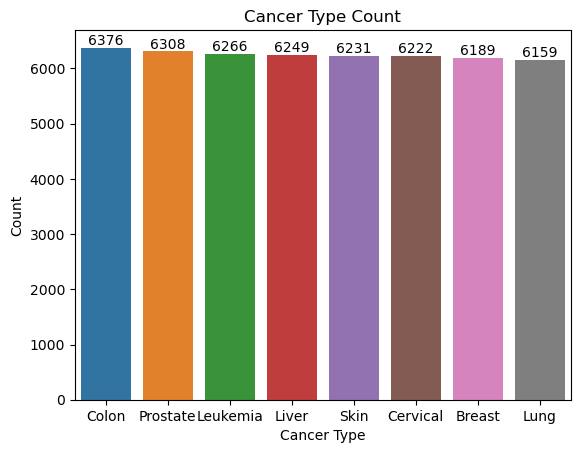

In [10]:
# Cancer type

data['Cancer_Type'].value_counts()

sns.barplot(x= data['Cancer_Type'].value_counts().index,
            y= data['Cancer_Type'].value_counts().values)

for i,v in enumerate(data['Cancer_Type'].value_counts()):
    plt.text(i,v,str(v), ha= 'center', va = 'bottom')

plt.title('Cancer Type Count')
plt.xlabel('Cancer Type')
plt.ylabel('Count')
plt.show()

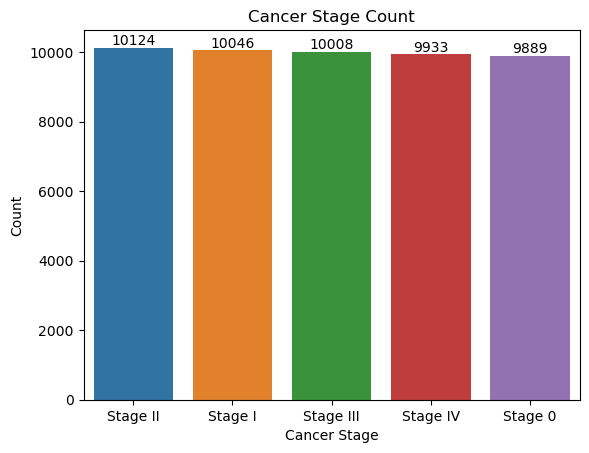

In [11]:
# Cancer stage

data['Cancer_Stage'].value_counts()

sns.barplot(x= data['Cancer_Stage'].value_counts().index,
            y= data['Cancer_Stage'].value_counts().values)

for i,v in enumerate(data['Cancer_Stage'].value_counts()):
    plt.text(i,v,str(v), ha= 'center', va = 'bottom')

plt.title('Cancer Stage Count')
plt.xlabel('Cancer Stage')
plt.ylabel('Count')
plt.show()

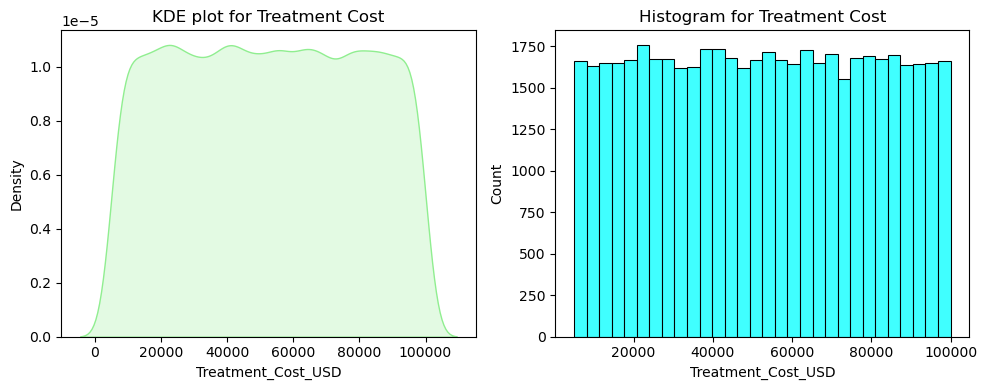

In [12]:
data['Treatment_Cost_USD']  

# plotting for age columns

plt.figure(figsize= (10,4))

plt.subplot(1,2,1)
sns.kdeplot(data['Treatment_Cost_USD'],fill= True, color= "lightgreen")
plt.title("KDE plot for Treatment Cost")

plt.subplot(1,2,2)
sns.histplot(data['Treatment_Cost_USD'], bins=30,color= "cyan")
plt.title('Histogram for Treatment Cost')

plt.tight_layout()
plt.show()

In [13]:
# Analysing Risk Factor

risk_factor= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
summary= data[risk_factor].agg(["mean", "std", "min", "max"])
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


### Relationship between risk factors and cancer secerity

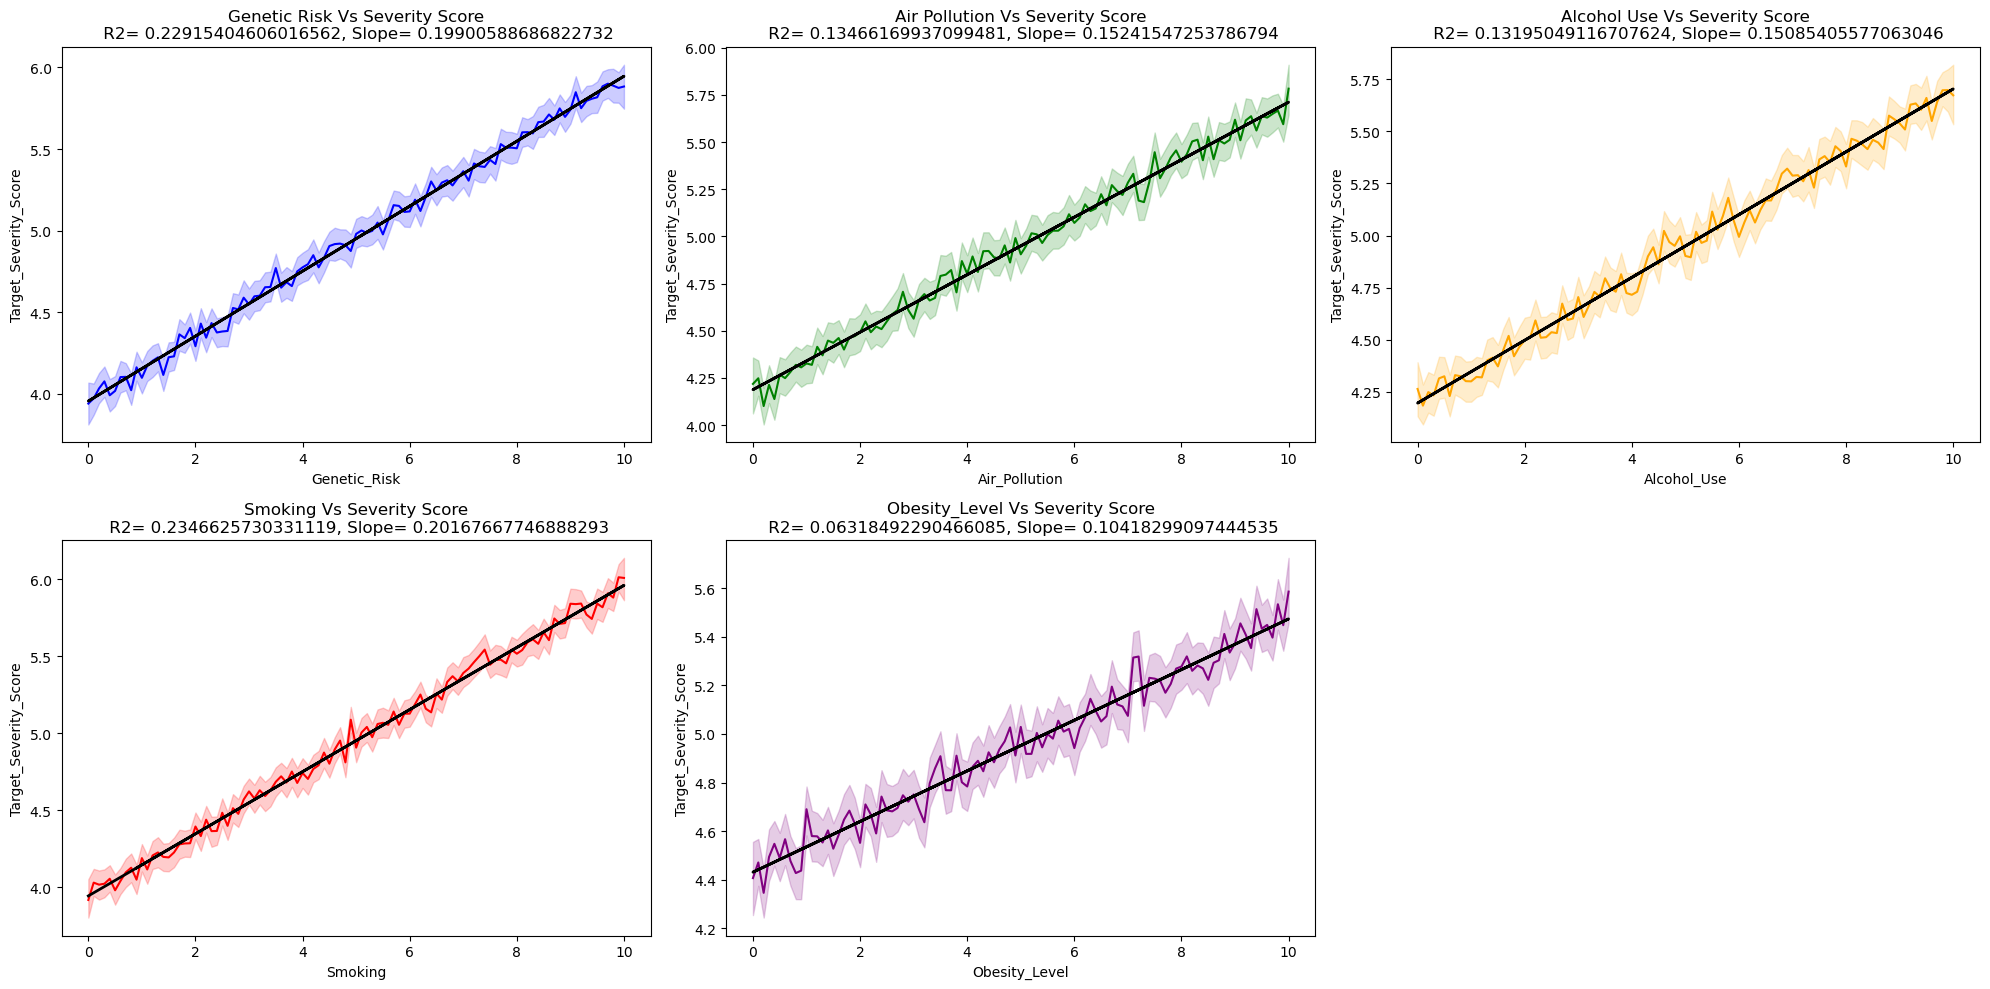

In [14]:
from scipy.stats import linregress

risk_factor= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles= ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity_Level']
colors= ['blue', 'green', 'orange', 'red', 'purple']

plt.figure(figsize= (20,10))
for i, (factor, title, color) in enumerate(zip(risk_factor, titles, colors), 1):
    plt.subplot(2,3,i)
    x= data[factor]
    y= data['Target_Severity_Score']
    slope, intercept, r_value, p_value, std_err= linregress(x,y)
    r_squared= r_value**2

    sns.lineplot(x= factor, y= 'Target_Severity_Score', data= data, color= color)
    plt.plot(x, x*slope+intercept, color= 'black', linewidth= 2, label= 'Rgression Line')
    plt.title(f'{title} Vs Severity Score\n R2= {r_squared}, Slope= {slope}')
    plt.xlabel(factor)
    plt.ylabel('Target_Severity_Score')

plt.tight_layout()
plt.show()

    


### Analyze proportion of early-diagnosis by cancer type

In [15]:
data['Cancer_Type'].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [16]:
cancer_type= data['Cancer_Type'].unique()

for i in cancer_type:
    stage_count= data[data['Cancer_Type']== i]['Cancer_Stage'].value_counts()
    early_stage_sum= stage_count.get('Stage 0',0)+ stage_count.get('Stage I',0)
    total_sum= stage_count.sum()
    proportion= (early_stage_sum/total_sum)*100
    print(f'proportion of {i} Cancer diagnosed at Stage0 and StageI: {proportion}')

proportion of Lung Cancer diagnosed at Stage0 and StageI: 38.43156356551388
proportion of Leukemia Cancer diagnosed at Stage0 and StageI: 39.53080114905841
proportion of Breast Cancer diagnosed at Stage0 and StageI: 39.47325900791727
proportion of Colon Cancer diagnosed at Stage0 and StageI: 40.41718946047679
proportion of Skin Cancer diagnosed at Stage0 and StageI: 40.41084898090194
proportion of Cervical Cancer diagnosed at Stage0 and StageI: 39.85856637737062
proportion of Prostate Cancer diagnosed at Stage0 and StageI: 40.187064045656314
proportion of Liver Cancer diagnosed at Stage0 and StageI: 40.614498319731155


### Identify key predictors of cancer severity and survival years

In [17]:
features= ['Age','Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

targets= ['Survival_Years', 'Target_Severity_Score']

# calculate corrleations

pearson_corr= data[features+targets].corr(method= 'pearson')
spearman_corr= data[features+targets].corr(method= 'spearman')

pearson_results= pearson_corr[targets]
spearman_results= spearman_corr[targets]

pd.concat([pearson_results,spearman_results], axis= 1, keys= ['Pearson', 'Spearman'])

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

For Severity Score

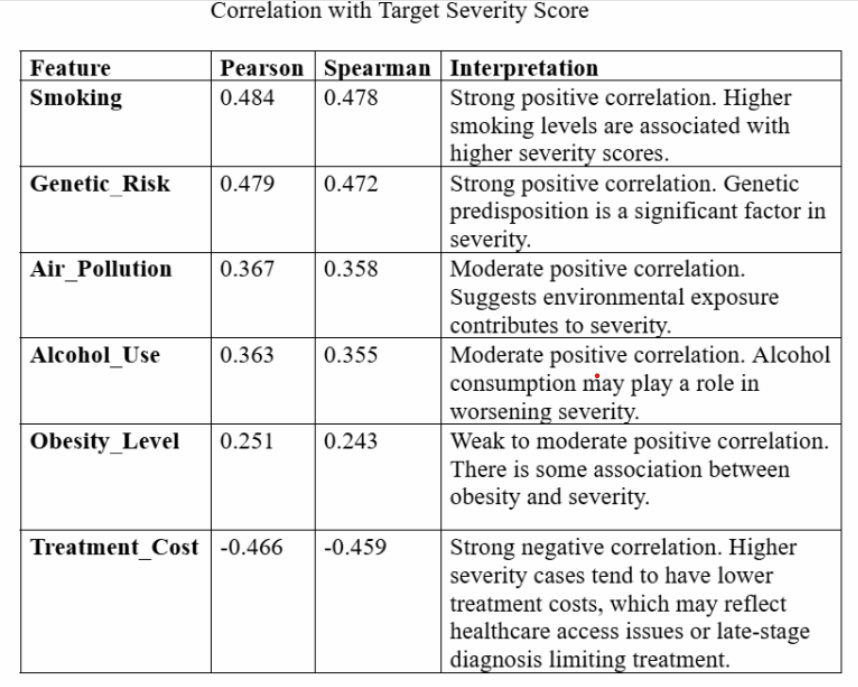

For survival years

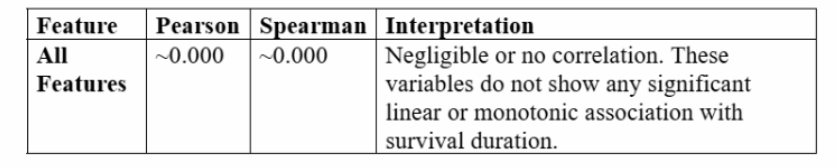

In [18]:
# Random forest for Target severity score

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score


# Convrting categorical columns to numerical

cat_cols1= ['Gender', 'Country_Region', 'Cancer_Type'] 

for col in cat_cols1:
    le= LabelEncoder()
    data[col]= le.fit_transform(data[col])
                

In [19]:
oe= OrdinalEncoder(categories= [['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']])
data['Cancer_Stage']= oe.fit_transform(data[['Cancer_Stage']]).astype(int)


In [21]:
x= data.drop(columns= ['Patient_ID', 'Survival_Years', 'Target_Severity_Score', 'Treatment_Cost_USD'])
y_severity= data['Target_Severity_Score']

X_train, X_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state= 42)

# Train random forest model

model= RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split= 2, min_samples_leaf= 1, random_state=42)
model.fit(X_train, y_train)

#evaluate the model

train_r2_severity= r2_score(y_train, model.predict(X_train))
test_r2_severity= r2_score(y_test, model.predict(X_test))

In [22]:
print(train_r2_severity)
print(test_r2_severity)

0.9689886894803543
0.7683892517466495


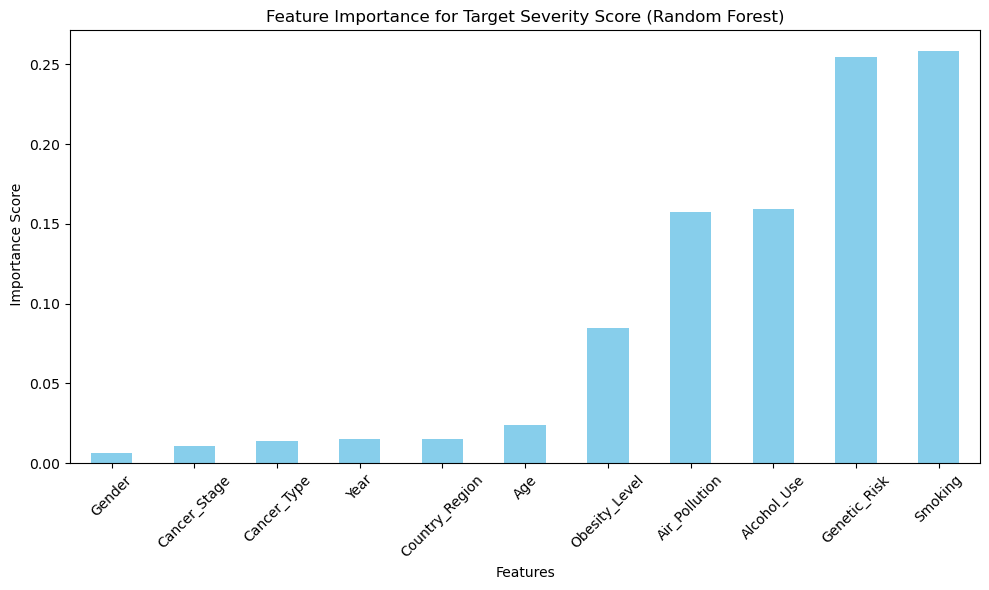

In [23]:
feature_importance_severity= pd.Series(model.feature_importances_, index= x.columns).sort_values()

# plotting for feature importances

plt.figure(figsize= (10,6))
feature_importance_severity.plot(kind='bar', color='skyblue')

plt.title('Feature Importance for Target Severity Score (Random Forest)')
plt.xlabel('Features')
plt.ylabel(' Importance Score')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV

x= data.drop(columns= ['Patient_ID', 'Survival_Years', 'Target_Severity_Score', 'Treatment_Cost_USD'])
y_severity= data['Survival_Years']

X_train, X_test, y_train, y_test=train_test_split(x,y_severity, test_size=0.2, random_state= 42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# train the model
model= RandomForestRegressor(random_state=40)
GSC= GridSearchCV(model , param_grid, cv=3, scoring="r2", n_jobs=-1)
GSC.fit(X_train, y_train)

best_rf_severity= GSC.best_estimator_

# evalaute the model
train_r2_severity= r2_score(y_train , best_rf_severity.predict(X_train))
test_r2_severity= r2_score(y_test , best_rf_severity.predict(X_test))



In [30]:
print(train_r2_severity)
print(test_r2_severity)

0.008880766282441277
0.00017030831704034632


<Axes: xlabel='Survival_Years', ylabel='Count'>

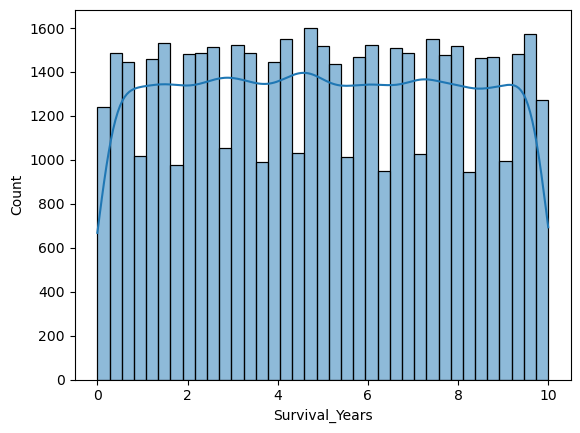

In [31]:
import seaborn as sns

sns.histplot(data=data['Survival_Years'], kde= True)

In [32]:
data.corr(numeric_only=True)['Survival_Years'].sort_values()

Gender                  -0.007121
Cancer_Stage            -0.003014
Cancer_Type             -0.001717
Alcohol_Use             -0.000527
Treatment_Cost_USD      -0.000429
Age                     -0.000147
Year                     0.000018
Air_Pollution            0.000893
Smoking                  0.001371
Genetic_Risk             0.001708
Target_Severity_Score    0.004161
Country_Region           0.005121
Obesity_Level            0.009771
Survival_Years           1.000000
Name: Survival_Years, dtype: float64

### Explore the economic burden of cancer treatment across different demographics and countries

In [34]:
df= pd.read_csv('global_cancer_patients_2015_2024 (1).csv')

In [37]:
df['Age_group']= pd.cut(df['Age'], bins= [0,30,45,60,75,100], labels= ['0-30', '30-45', '45-60','61-75', '76+'])

Text(0.5, 1.0, 'Average cancer treatment cost by Country and Gender')

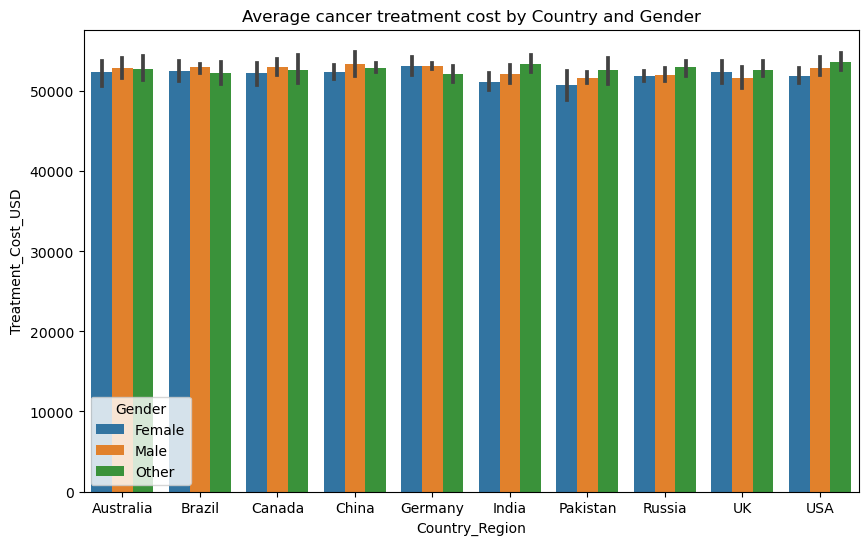

In [44]:
country_gender_cost= df.groupby(['Country_Region', 'Age_group', 'Gender'])['Treatment_Cost_USD'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data= country_gender_cost, x= 'Country_Region', y= 'Treatment_Cost_USD', hue= 'Gender')
plt.title('Average cancer treatment cost by Country and Gender')

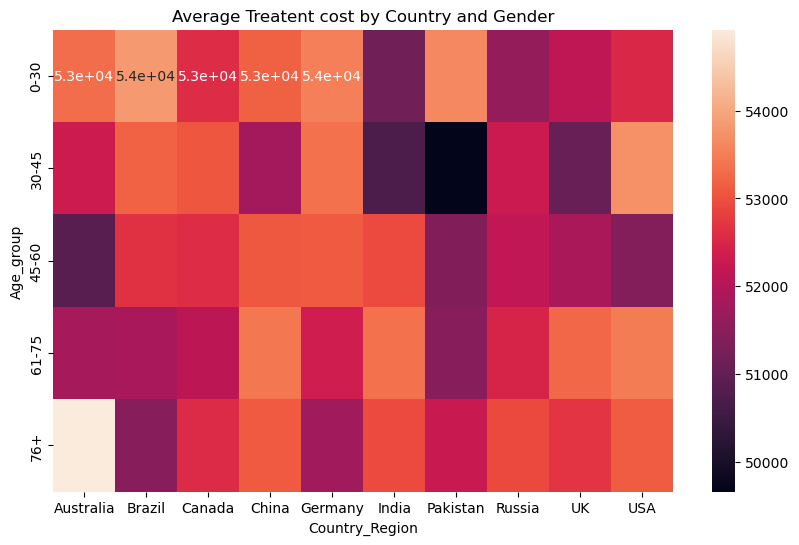

In [46]:
country_age_cost= df.groupby(['Country_Region', 'Age_group'])['Treatment_Cost_USD'].mean().reset_index()
heatmap_data= country_age_cost.pivot(index= 'Age_group', columns= 'Country_Region', values= 'Treatment_Cost_USD')


plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot= True)
plt.title('Average Treatent cost by Country and Gender')
plt.show()

### Assess whether higher treatment cost is associated with longer survival

In [48]:
from scipy.stats import pearsonr, spearmanr

x=df['Treatment_Cost_USD']
y= df['Survival_Years']

pearson_corr, pearson_p = pearsonr(x,y)
print(f'Pearson Correlation:{pearson_corr}')
print(f'Pearson p-values: {pearson_p}')

spearman_corr, spearman_corr = spearmanr(x,y)
print(f'Spearman Correlation:{spearman_corr}')
print(f'Spearman p-values: {spearman_p}')

alpha= 0.05

def interpret_corr( corr, p, method):
    if p<alpha:
        print(f'{method}: We reject the null hypothesis')
    else:
        print(f'{method}: We fail to reject null hyothesis')

interpret_corr(pearson_corr,pearson_p, "Pearson")
interpret_corr(spearman_corr,spearman_corr, "Spearman")





Pearson Correlation:-0.00042940542830214993
Pearson p-values: 0.9235082012963326
Spearman Correlation:0.9206551702014918
Spearman p-values: 0.9206551702014918
Pearson: We fail to reject null hyothesis
Spearman: We fail to reject null hyothesis


<Axes: xlabel='Treatment_Cost_USD', ylabel='Survival_Years'>

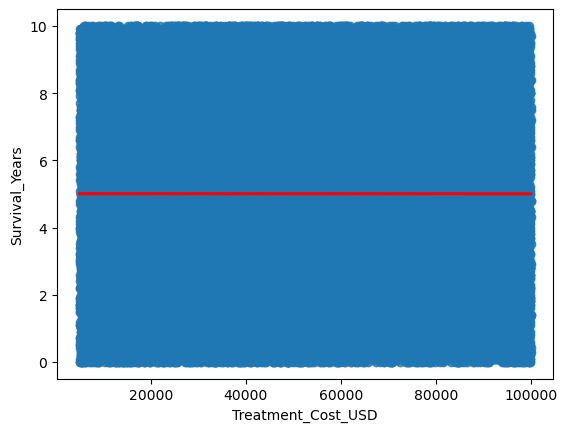

In [50]:
sns.regplot(x=x, y=y, line_kws= {'color': 'red'})

### Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years

In [81]:
data= df.copy()

In [82]:
stage_order = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']

In [83]:
grouped_stats= data.groupby('Cancer_Stage')[['Treatment_Cost_USD', 'Survival_Years']].mean().reset_index()
grouped_stats

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


In [84]:
grouped_costs=[]
grouped_survival=[]


for  stage in stage_order:
    stage_data= df[df["Cancer_Stage"]==stage]
    cost= stage_data["Treatment_Cost_USD"]
    survival= stage_data["Survival_Years"]
    grouped_costs.append(cost)
    grouped_survival.append(survival)
    

In [85]:
# check for normaility
from scipy.stats import  shapiro, f_oneway
normal_cost=0
normal_survival=0

for i in range (len(stage_order)):
    cost_p= shapiro(grouped_costs[i]).pvalue
    surv_p= shapiro(grouped_survival[i]).pvalue 
    print(f" cost {cost_p} for group {i}")
    print(f"Survival {surv_p} for group {i}")
    if cost_p<0.05:
        normal_cost+=1
    if surv_p<0.05:
        normal_survival+=1



 cost 0.0 for group 0
Survival 0.0 for group 0
 cost 0.0 for group 1
Survival 0.0 for group 1
 cost 0.0 for group 2
Survival 0.0 for group 2
 cost 0.0 for group 3
Survival 0.0 for group 3
 cost 0.0 for group 4
Survival 0.0 for group 4


In [86]:
print(normal_cost)
print(normal_survival)

# For none of the group there is normal distribution. So we cant apply ANOVA test on the dtaa.

5
5


In [87]:
# We will use Kruskal test

from scipy.stats import kruskal

In [92]:
kruskal_cost= kruskal(*grouped_costs)
kruskal_survival= kruskal(*grouped_survival)

p_cost= kruskal_cost.pvalue
p_survival= kruskal_survival.pvalue

In [93]:
print(p_cost)
print(p_survival)

0.4254451689062656
0.6033078729984223


In [96]:
def interpret_p(p, feat):
    if p<alpha:
        print(f'{feat}: We reject the null hypothesis')
    else:
        print(f'{feat}: We fail to reject null hyothesis.')

interpret_p(p_cost, "Cost")
interpret_p(p_survival, "Survival Years")

Cost: We fail to reject null hyothesis.
Survival Years: We fail to reject null hyothesis.


### Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity 

In [101]:
import statsmodels.formula.api as smf

model = smf.ols("Target_Severity_Score ~ Genetic_Risk*Smoking", data=data).fit()

model.summary2().tables[1].loc["Genetic_Risk:Smoking"]

Coef.      -0.000228
Std.Err.    0.000471
t          -0.484187
P>|t|       0.628255
[0.025     -0.001150
0.975]      0.000694
Name: Genetic_Risk:Smoking, dtype: float64